# 12-vtrain2 — TCN Grid Search with 5 Mechanical Fixes

## What changed vs vtrain1

| Fix | vtrain1 (broken) | vtrain2 (fixed) |
|-----|------------------|-----------------|
| K-Fold early stopping | global 2024 val_df for all 5 folds (look-ahead) | fold-specific temporal window before fold start |
| Backtest execution | hourly trailing exit vs TBM training objective | TBM barrier logic: hold until upper/lower/vert hit |
| SL/TP check | close-only (misses intra-candle touches) | intra-candle: uses high/low arrays |
| Transaction fees | none (0%) | 0.1% per side (0.2% round-trip) |
| Parameter optimisation | static params applied to test set directly | WFO: monthly fine-tuning, warm-start weights |

## Architecture

- **Phase 1**: Purged K-Fold (K=5, embargo=168h) with fold-specific internal validation  
- **Phase 2**: Grid search on OOS probs using TBM-aligned backtest (intra-candle, fees)  
- **Phase 3**: WFO on test period — monthly 5-epoch warm-start fine-tuning, TBM backtest with fees

**Estimated runtime: ~60-120 min on M4 MPS.**

In [1]:
# ── Purged K-Fold config ──────────────────────────────────────────────────────
K                    = 5
EMBARGO              = 168     # bars (1 week @ 1h)
KFOLD_INTERNAL_VAL_H = 1500    # fold-specific val window size (pre-fold bars)
EPOCHS_FOLD          = 60
PATIENCE_FOLD        = 10

# ── WFO config ────────────────────────────────────────────────────────────────
WFO_STEP_H           = 720     # monthly steps
WFO_FINETUNE_WINDOW  = 2880    # rolling 4-month fine-tuning window
WFO_FINETUNE_EPOCHS  = 5
WFO_PATIENCE         = 3
WFO_LR               = 5e-4
WFO_INTERNAL_VAL_H   = 500     # val window within WFO fine-tuning

# ── Fees ─────────────────────────────────────────────────────────────────────
FEE_RATE = 0.001   # 0.1% per side

# ── Grid (TBM execution: no atr_mult/tp params — barriers from vol) ──────────
GRID = {
    'long_threshold':  [0.36, 0.40, 0.44, 0.48, 0.52],
    'short_threshold': [0.36, 0.40, 0.44, 0.48, 0.52],
    'cooldown':        [0, 1, 2, 3],
}

MIN_TRADES      = 20
OPTIMISE_METRIC = 'sharpe'

# ── Model / data settings (must match notebook 11) ───────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

FRAC_D    = 0.4
FFD_THRES = 1e-4

TBM_VOL_WINDOW = 24
TBM_PT         = 1.0
TBM_SL         = 1.0
TBM_VERT_H     = 12
AUX_FWD_H      = 6

SEQ_LEN = 24

TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL   = 3
TCN_DROPOUT  = 0.40

WARMUP_EPOCHS = 5
BATCH_SIZE    = 256
LR            = 2e-3
WEIGHT_DECAY  = 1e-3
LAMBDA_VOL    = 0.5

SEED = 42

In [2]:
import copy
import itertools
import json
import math
import pickle
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED    = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT:  {REPO_ROOT}')
print(f'MODELS_DIR: {MODELS_DIR}')

Device: mps
REPO_ROOT:  /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


In [3]:
# ── Load features parquet ─────────────────────────────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    BACKTEST_COLS = json.load(f)['backtest_only_cols']

selected_features = pd.read_csv(MODELS_DIR / 'lgbm_features.csv', header=None)[0].tolist()
missing = [f for f in selected_features if f not in feat_df.columns]
if missing:
    raise ValueError(f'Features missing from parquet: {missing}')

# ── Join high/low from raw parquet (dropped from features parquet) ────────────
raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])

# ── FFD functions ─────────────────────────────────────────────────────────────
def _ffd_weights(d, thres=1e-4):
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < thres: break
        w.append(w_k); k += 1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    weights = _ffd_weights(d, thres)
    width   = len(weights)
    vals    = series.values.astype(np.float64)
    out     = np.full(len(vals), np.nan)
    for i in range(width - 1, len(vals)):
        out[i] = np.dot(weights, vals[i - width + 1 : i + 1])
    return pd.Series(out, index=series.index)

# ── FracDiff close ────────────────────────────────────────────────────────────
log_close      = np.log(feat_df['close'])
fracdiff_close = frac_diff_ffd(log_close, FRAC_D, FFD_THRES)
feat_df['fracdiff_close'] = fracdiff_close

# ── Rolling vol (used at entry for TBM barrier sizing) ────────────────────────
log_rets    = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
feat_df['rolling_vol'] = rolling_vol

# ── TBM labels (using intra-candle high/low for barrier checking) ─────────────
close_vals = feat_df['close'].values
high_vals  = feat_df['high'].values
low_vals   = feat_df['low'].values
vol_vals   = rolling_vol.values
n          = len(close_vals)
tbm_labels = np.full(n, np.nan)

for i in range(n - TBM_VERT_H):
    if np.isnan(vol_vals[i]) or vol_vals[i] <= 0: continue
    entry = close_vals[i]
    upper = entry * (1 + TBM_PT * vol_vals[i])
    lower = entry * (1 - TBM_SL * vol_vals[i])
    lbl   = 2
    for j in range(1, TBM_VERT_H + 1):
        hi = high_vals[i + j]; lo = low_vals[i + j]
        if lo <= lower and hi >= upper:
            lbl = 0; break   # SL wins on ambiguous candle
        elif lo <= lower:
            lbl = 0; break
        elif hi >= upper:
            lbl = 1; break
    tbm_labels[i] = lbl
feat_df['tbm_label'] = tbm_labels

# ── Aux vol + sample weights ──────────────────────────────────────────────────
fwd_vol = pd.concat([log_rets.shift(-h) for h in range(1, AUX_FWD_H + 1)], axis=1).std(axis=1)
feat_df['fwd_vol'] = fwd_vol
w_raw = rolling_vol.fillna(rolling_vol.median()) / rolling_vol.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)

# ── Build clean_df & split ────────────────────────────────────────────────────
ALL_INPUT_FEATS = selected_features + ['fracdiff_close']
required_cols   = ALL_INPUT_FEATS + ['tbm_label', 'fwd_vol', 'sample_weight',
                                      'rolling_vol', 'high', 'low'] + BACKTEST_COLS
clean_df        = feat_df[required_cols].dropna()

train_df, val_df, test_df = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Loaded {len(feat_df):,} total rows')
print(f'After NaN drop: {len(clean_df):,} rows')
print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Input features: {len(ALL_INPUT_FEATS)}')

Loaded 74,366 total rows
After NaN drop: 74,073 rows
Train:  56,949  2017-11-27 → 2024-06-01
Val:     3,888  2024-06-01 → 2024-11-10
Test:   13,236  2024-11-10 → 2026-05-15
Input features: 51


In [4]:
# ── TCN model definition (identical to notebook 11 / saved tcn_model.pt) ─────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad))
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation), nn.ReLU(True), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation), nn.ReLU(True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x) + res)

class TCNMultiTask(nn.Module):
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks, in_ch = [], input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch, ch, kernel, 2**i, dropout)); in_ch = ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, 32), nn.GELU(),
            nn.Dropout(dropout * .5), nn.Linear(32, 3))
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, 16), nn.GELU(),
            nn.Linear(16, 1), nn.Softplus())
    def forward(self, x):
        out  = self.tcn(x.transpose(1, 2))
        last = out[:, :, -1]
        return self.head_dir(last), self.head_vol(last).squeeze(-1)

n_params = sum(p.numel() for p in TCNMultiTask(
    len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
print(f'TCNMultiTask: {n_params:,} parameters')

def make_lr_lambda(total_epochs, warmup):
    def lr_lambda(epoch):
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(1, total_epochs - warmup)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return lr_lambda

TCNMultiTask: 103,652 parameters


In [5]:
# ── Fit QuantileTransformer ONCE on all training data ─────────────────────────
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
qt.fit(train_df[ALL_INPUT_FEATS].values)
print(f'QuantileTransformer fitted on train_df: {train_df[ALL_INPUT_FEATS].shape}')

# Pre-transform training matrix
X_train_qt  = qt.transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)
y_train_all = train_df['tbm_label'].values.astype(np.int64)
w_train_all = train_df['sample_weight'].values.astype(np.float32)
v_train_all = train_df['fwd_vol'].values.astype(np.float32)

# Backtest arrays for training period (grid search)
train_close_arr   = train_df['close'].values.astype(np.float64)
train_high_arr    = train_df['high'].values.astype(np.float64)
train_low_arr     = train_df['low'].values.astype(np.float64)
train_vol_arr     = train_df['rolling_vol'].values.astype(np.float64)
train_index       = train_df.index

N_TRAIN = len(train_df)
print(f'N_TRAIN: {N_TRAIN:,}')
print(f'QT fitted. Pre-transformed X_train_qt: {X_train_qt.shape}')

QuantileTransformer fitted on train_df: (56949, 51)
N_TRAIN: 56,949
QT fitted. Pre-transformed X_train_qt: (56949, 51)


## Phase 1 — Purged K-Fold with Fold-Specific Internal Validation

**Fix applied**: vtrain1 used the global 2024 `val_df` (future data) for early stopping in all 5 folds —
a systematic look-ahead bias. vtrain2 uses a fold-specific temporal window **before each fold start**
as the internal validation set.

- Folds 2-5: internal val = `[emb_start - KFOLD_INTERNAL_VAL_H, emb_start)` (pre-fold, temporally prior)
- Fold 1: no pre-fold data available → use `[emb_end, emb_end + KFOLD_INTERNAL_VAL_H)` (post-embargo)

The internal val rows are excluded from training (added to the training mask exclusion zone).

In [6]:
oos_up   = np.full(N_TRAIN, np.nan, dtype=np.float32)
oos_down = np.full(N_TRAIN, np.nan, dtype=np.float32)

fold_size = N_TRAIN // K
print(f'K={K}  fold_size≈{fold_size:,}  EMBARGO={EMBARGO}  INT_VAL={KFOLD_INTERNAL_VAL_H}')

for k in range(K):
    print(f'\n{"="*60}')
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else N_TRAIN
    emb_start  = max(0,       fold_start - EMBARGO)
    emb_end    = min(N_TRAIN, fold_end   + EMBARGO)
    print(f'Fold {k+1}/{K}: rows [{fold_start},{fold_end})  embargo [{emb_start},{emb_end})')

    # ── Fold-specific internal validation window ──────────────────────────────
    if emb_start >= KFOLD_INTERNAL_VAL_H:
        # Folds 2-5: pre-fold temporal window
        int_end   = emb_start
        int_start = max(SEQ_LEN, emb_start - KFOLD_INTERNAL_VAL_H)
        int_source = f'pre-fold [{int_start},{int_end})'
    else:
        # Fold 1: no pre-fold data — use post-embargo
        int_start = max(SEQ_LEN, emb_end)
        int_end   = min(N_TRAIN, int_start + KFOLD_INTERNAL_VAL_H)
        int_source = f'post-emb [{int_start},{int_end})'
    n_int = int_end - int_start
    print(f'  Internal val: {int_source}  ({n_int} rows)')

    # Build internal val sequences
    ctx_s = int_start - (SEQ_LEN - 1)
    X_int_ctx  = X_train_qt[max(0, ctx_s) : int_end]
    offset_int = int_start - max(0, ctx_s)
    X_vl_seqs  = []
    for i in range(offset_int, len(X_int_ctx)):
        if i >= SEQ_LEN:
            X_vl_seqs.append(X_int_ctx[i - SEQ_LEN : i])
    n_vl = len(X_vl_seqs)

    if n_vl == 0:
        print(f'  WARNING: fold {k+1} internal val has no sequences — skipping')
        continue

    X_vl_fold = torch.from_numpy(np.array(X_vl_seqs, dtype=np.float32))
    y_vl_fold = torch.from_numpy(y_train_all[int_end - n_vl : int_end].copy())
    v_vl_fold = torch.from_numpy(v_train_all[int_end - n_vl : int_end].copy())
    print(f'  Val seqs: {n_vl:,}  shapes: X={X_vl_fold.shape} y={y_vl_fold.shape}')

    # ── Training mask: exclude fold + embargo + internal val ─────────────────
    train_mask = np.ones(N_TRAIN, dtype=bool)
    train_mask[emb_start:emb_end]   = False
    train_mask[int_start:int_end]   = False
    train_indices = np.where(train_mask)[0]

    # ── Contiguous segments → training sequences ─────────────────────────────
    if len(train_indices) > 1:
        gaps = np.where(np.diff(train_indices) > 1)[0]
        seg_boundaries = np.concatenate([[0], gaps + 1, [len(train_indices)]])
    else:
        seg_boundaries = np.array([0, len(train_indices)])

    X_fold_seqs, y_fold_seqs, w_fold_seqs, v_fold_seqs = [], [], [], []
    for s_start, s_end in zip(seg_boundaries[:-1], seg_boundaries[1:]):
        seg_idx = train_indices[s_start:s_end]
        seg_len = len(seg_idx)
        if seg_len < SEQ_LEN: continue
        for i in range(SEQ_LEN - 1, seg_len):
            window = seg_idx[i - SEQ_LEN + 1 : i + 1]
            X_fold_seqs.append(X_train_qt[window])
            y_fold_seqs.append(y_train_all[seg_idx[i]])
            w_fold_seqs.append(w_train_all[seg_idx[i]])
            v_fold_seqs.append(v_train_all[seg_idx[i]])

    X_tr = torch.tensor(np.array(X_fold_seqs, dtype=np.float32))
    y_tr = torch.tensor(np.array(y_fold_seqs, dtype=np.int64))
    w_tr = torch.tensor(np.array(w_fold_seqs, dtype=np.float32))
    v_tr = torch.tensor(np.array(v_fold_seqs, dtype=np.float32))
    print(f'  Train seqs: {len(X_tr):,}')

    class_counts  = np.bincount(y_tr.numpy(), minlength=3).astype(np.float32)
    class_weights = torch.tensor(
        class_counts.sum() / (3 * class_counts + 1e-8), dtype=torch.float32).to(DEVICE)

    model     = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=make_lr_lambda(EPOCHS_FOLD, WARMUP_EPOCHS))

    loader_tr = DataLoader(TensorDataset(X_tr, y_tr, w_tr, v_tr),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
    loader_vl = DataLoader(TensorDataset(X_vl_fold, y_vl_fold,
                                          torch.ones(len(y_vl_fold)), v_vl_fold),
                           batch_size=512, shuffle=False, num_workers=0)

    best_val_loss = np.inf; patience_count = 0; best_state = None

    for epoch in range(EPOCHS_FOLD):
        model.train()
        for xb, yb, wb, vb in loader_tr:
            xb, yb, wb, vb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE), vb.to(DEVICE)
            optimizer.zero_grad()
            logits, vol_pred = model(xb)
            ce_per  = F.cross_entropy(logits, yb, weight=class_weights, reduction='none')
            hub_per = F.huber_loss(vol_pred, vb, reduction='none')
            loss    = (ce_per * wb).mean() + LAMBDA_VOL * (hub_per * wb).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        model.eval(); val_acc = 0.0
        with torch.no_grad():
            for xb, yb, _, vb in loader_vl:
                xb, yb, vb = xb.to(DEVICE), yb.to(DEVICE), vb.to(DEVICE)
                lgts, vp = model(xb)
                val_acc += (F.cross_entropy(lgts, yb) + LAMBDA_VOL * F.huber_loss(vp, vb)).item() * len(xb)
        val_loss = val_acc / max(len(loader_vl.dataset), 1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {kk: vv.cpu().clone() for kk, vv in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= PATIENCE_FOLD:
            print(f'  Early stop ep {epoch+1}  best_val={best_val_loss:.5f}')
            break
        if (epoch + 1) % 10 == 0:
            print(f'  Ep {epoch+1:>3}/{EPOCHS_FOLD}  val={val_loss:.5f}  best={best_val_loss:.5f}  pat={patience_count}')

    model.load_state_dict(best_state)

    # ── OOS inference on fold rows ────────────────────────────────────────────
    lookback_start      = max(0, fold_start - (SEQ_LEN - 1))
    X_fold_context      = X_train_qt[lookback_start:fold_end]
    offset              = fold_start - lookback_start
    X_fold_pred_seqs    = []
    fold_pred_positions = []

    for i in range(offset, len(X_fold_context)):
        if i >= SEQ_LEN:
            X_fold_pred_seqs.append(X_fold_context[i - SEQ_LEN:i])
            fold_pred_positions.append(lookback_start + i)

    if len(X_fold_pred_seqs) == 0:
        print(f'  WARNING: no pred seqs for fold {k+1}')
        model.cpu(); del model
        if DEVICE.type == 'mps': torch.mps.empty_cache()
        continue

    model.eval(); logits_list = []
    with torch.no_grad():
        for xb, in DataLoader(TensorDataset(
                torch.from_numpy(np.array(X_fold_pred_seqs, dtype=np.float32))), batch_size=512):
            lgts, _ = model(xb.to(DEVICE))
            logits_list.append(lgts.cpu())

    probs_fold = torch.softmax(torch.cat(logits_list), dim=1).numpy()
    for pos, p_down, p_up in zip(fold_pred_positions, probs_fold[:, 0], probs_fold[:, 1]):
        oos_down[pos] = p_down
        oos_up[pos]   = p_up

    model.cpu(); del model
    if DEVICE.type == 'mps': torch.mps.empty_cache()
    elif DEVICE.type == 'cuda': torch.cuda.empty_cache()
    print(f'  Fold {k+1}/{K} done: {len(probs_fold):,} OOS preds stored')

valid_mask = ~np.isnan(oos_up)
print(f'\nOOS coverage: {valid_mask.sum():,}/{N_TRAIN:,} ({valid_mask.mean()*100:.1f}%)')

K=5  fold_size≈11,389  EMBARGO=168  INT_VAL=1500

Fold 1/5: rows [0,11389)  embargo [0,11557)
  Internal val: post-emb [11557,13057)  (1500 rows)
  Val seqs: 1,499  shapes: X=torch.Size([1499, 24, 51]) y=torch.Size([1499])
  Train seqs: 43,869
  Ep  10/60  val=0.70236  best=0.70236  pat=0
  Ep  20/60  val=0.70654  best=0.69765  pat=6
  Early stop ep 24  best_val=0.69765
  Fold 1/5 done: 11,365 OOS preds stored

Fold 2/5: rows [11389,22778)  embargo [11221,22946)
  Internal val: pre-fold [9721,11221)  (1500 rows)
  Val seqs: 1,499  shapes: X=torch.Size([1499, 24, 51]) y=torch.Size([1499])
  Train seqs: 43,678
  Ep  10/60  val=0.79554  best=0.74425  pat=2
  Early stop ep 18  best_val=0.74425
  Fold 2/5 done: 11,388 OOS preds stored

Fold 3/5: rows [22778,34167)  embargo [22610,34335)
  Internal val: pre-fold [21110,22610)  (1500 rows)
  Val seqs: 1,499  shapes: X=torch.Size([1499, 24, 51]) y=torch.Size([1499])
  Train seqs: 43,678
  Ep  10/60  val=0.83354  best=0.79130  pat=1
  Ep  20/60

OOS rows: 56,921
Date range: 2017-11-28 → 2024-06-01
P(up)   mean=0.4724  std=0.0748
P(down) mean=0.4902  std=0.0756


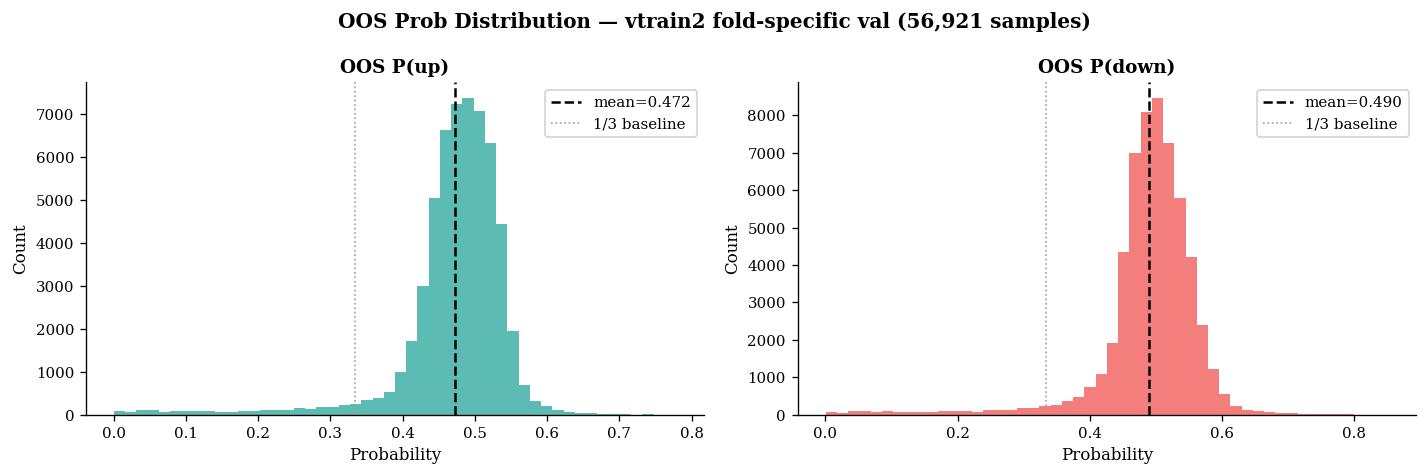

In [7]:
# ── Align OOS arrays for backtest ─────────────────────────────────────────────
valid_mask     = ~np.isnan(oos_up)
oos_up_v       = oos_up[valid_mask]
oos_down_v     = oos_down[valid_mask]
oos_close_v    = train_close_arr[valid_mask]
oos_high_v     = train_high_arr[valid_mask]
oos_low_v      = train_low_arr[valid_mask]
oos_vol_v      = train_vol_arr[valid_mask]
oos_index_v    = train_index[valid_mask]
bh_equity_oos  = oos_close_v / oos_close_v[0]

print(f'OOS rows: {len(oos_up_v):,}')
print(f'Date range: {oos_index_v.min().date()} → {oos_index_v.max().date()}')
print(f'P(up)   mean={oos_up_v.mean():.4f}  std={oos_up_v.std():.4f}')
print(f'P(down) mean={oos_down_v.mean():.4f}  std={oos_down_v.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, prob, label, color in [
    (axes[0], oos_up_v,   'OOS P(up)',   GREEN),
    (axes[1], oos_down_v, 'OOS P(down)', RED),
]:
    ax.hist(prob, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(prob.mean(), color='black', ls='--', lw=1.5, label=f'mean={prob.mean():.3f}')
    ax.axvline(1/3, color=GREY, ls=':', lw=1, label='1/3 baseline')
    ax.set_xlabel('Probability'); ax.set_ylabel('Count')
    ax.set_title(label, fontweight='bold'); ax.legend()
fig.suptitle(f'OOS Prob Distribution — vtrain2 fold-specific val ({len(oos_up_v):,} samples)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_oos_prob_distribution_vtrain2.png')
plt.show()

## Phase 2 — Grid Search with TBM-Aligned Backtest

**Fixes applied**:
1. **TBM barrier execution**: barriers set from `rolling_vol` at entry — model is trained to predict exactly these events. Hold until upper/lower hit or `TBM_VERT_H` bars elapsed (no arbitrary `min_hold`/`max_hold`).
2. **Intra-candle checking**: use `high[]` and `low[]` arrays to detect barrier touches within each candle.
3. **Fees**: `FEE_RATE=0.001` applied at both entry and exit.

Grid is simplified to just `long_threshold`, `short_threshold`, and `cooldown`.

In [8]:
def run_backtest_tbm(
    probs_up, probs_down, close_arr, high_arr, low_arr, vol_arr,
    params, tbm_pt=TBM_PT, tbm_sl=TBM_SL, vert_h=TBM_VERT_H, fee=FEE_RATE
):
    lt  = params['long_threshold']
    st  = params['short_threshold']
    cd  = params['cooldown']
    N   = len(close_arr)

    cash      = 1.0; units = 0.0
    in_pos    = False; direction = None
    entry_px  = 0.0; entry_cash = 0.0
    upper     = 0.0; lower = 0.0
    bars_held = 0; cooldown = 0
    equity    = np.empty(N, dtype=np.float64)

    n_long = n_short = n_sl = n_tp = n_vert = 0
    wins   = 0; total_pnl = 0.0

    for i in range(N):
        px   = close_arr[i]
        hi   = high_arr[i]
        lo   = low_arr[i]
        p_up = probs_up[i]
        p_dn = probs_down[i]
        vol  = vol_arr[i]

        if cooldown > 0: cooldown -= 1

        if in_pos:
            bars_held += 1
            reason = None; exit_px = px

            if direction == 'long':
                sl_hit = lo <= lower
                tp_hit = hi >= upper
                if sl_hit and tp_hit:
                    reason = 'sl'; exit_px = lower   # conservative: SL wins on ambiguous candle
                elif sl_hit:
                    reason = 'sl'; exit_px = lower
                elif tp_hit:
                    reason = 'tp'; exit_px = upper
                elif bars_held >= vert_h:
                    reason = 'vert'; exit_px = px
                if reason:
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - fee)
                    units = 0.0
            else:  # short
                sl_hit = hi >= upper   # upper = SL for short
                tp_hit = lo <= lower   # lower = TP for short
                if sl_hit and tp_hit:
                    reason = 'sl'; exit_px = upper
                elif sl_hit:
                    reason = 'sl'; exit_px = upper
                elif tp_hit:
                    reason = 'tp'; exit_px = lower
                elif bars_held >= vert_h:
                    reason = 'vert'; exit_px = px
                if reason:
                    pnl  = (entry_px - exit_px) / entry_px
                    cash = entry_cash * (1.0 + pnl) * (1.0 - fee)

            if reason:
                if reason == 'sl':   n_sl   += 1
                elif reason == 'tp': n_tp   += 1
                else:                n_vert += 1
                wins += int(pnl > 0); total_pnl += pnl
                in_pos = False; bars_held = 0; cooldown = cd

        if not in_pos and cooldown == 0 and not np.isnan(vol) and vol > 0:
            if p_up >= lt:
                dyn_upper = px * (1.0 + tbm_pt * vol)
                dyn_lower = px * (1.0 - tbm_sl * vol)
                units     = cash * (1.0 - fee) / px
                cash      = 0.0
                in_pos = True; direction = 'long'
                entry_px = px; upper = dyn_upper; lower = dyn_lower
                bars_held = 0; n_long += 1
            elif p_dn >= st and p_up < lt:
                dyn_upper = px * (1.0 + tbm_sl * vol)   # SL for short
                dyn_lower = px * (1.0 - tbm_pt * vol)   # TP for short
                entry_cash = cash * (1.0 - fee)
                cash = 0.0; units = entry_cash / px
                in_pos = True; direction = 'short'
                entry_px = px; upper = dyn_upper; lower = dyn_lower
                bars_held = 0; n_short += 1

        if in_pos and direction == 'long':
            equity[i] = units * px
        elif in_pos and direction == 'short':
            equity[i] = entry_cash * (1.0 + (entry_px - px) / entry_px)
        else:
            equity[i] = cash

    # Force-close at end
    if in_pos:
        px  = close_arr[-1]
        if direction == 'long':
            pnl = (px - entry_px) / entry_px
            cash = units * px * (1.0 - fee)
        else:
            pnl  = (entry_px - px) / entry_px
            cash = entry_cash * (1.0 + pnl) * (1.0 - fee)
        wins += int(pnl > 0); total_pnl += pnl
        equity[-1] = cash

    n_trades = n_long + n_short
    if n_trades < MIN_TRADES: return None

    eq = equity
    r  = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    sharpe = float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)) if len(r) > 1 else 0.0
    pk     = np.maximum.accumulate(eq)
    dd_arr = (eq - pk) / (pk + 1e-12)
    max_dd = float(dd_arr.min())
    calmar = float((eq[-1] - 1) / (-max_dd + 1e-12)) if max_dd < 0 else 0.0
    win_rate = wins / n_trades
    avg_pnl  = total_pnl / n_trades
    wins_pnl = total_pnl * (wins / n_trades) / max(wins / n_trades, 1e-12)
    loss_pnl = total_pnl - wins_pnl
    pf_denom = abs(loss_pnl * (n_trades - wins)) if (n_trades - wins) > 0 else 1e-12
    profit_factor = abs(wins_pnl * wins / pf_denom) if pf_denom > 0 else 0.0

    return {
        **params,
        'n_trades': n_trades, 'n_long': n_long, 'n_short': n_short,
        'n_sl': n_sl, 'n_tp': n_tp, 'n_vert': n_vert,
        'total_return': float(eq[-1] - 1),
        'sharpe': sharpe, 'max_dd': max_dd, 'calmar': calmar,
        'win_rate': win_rate, 'avg_pnl': avg_pnl, 'profit_factor': profit_factor,
        'bh_return': float(bh_equity_oos[-1] - 1),
        'alpha': float(eq[-1] - bh_equity_oos[-1]),
    }

print('run_backtest_tbm() defined.')
print(f'BH return on OOS period: {(bh_equity_oos[-1]-1)*100:+.2f}%')

run_backtest_tbm() defined.
BH return on OOS period: +603.44%


In [9]:
import time

keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos)}')

results = []
for vals in tqdm(combos, desc='Grid search (OOS TBM)', ncols=80):
    p   = dict(zip(keys, vals))
    out = run_backtest_tbm(oos_up_v, oos_down_v, oos_close_v, oos_high_v, oos_low_v, oos_vol_v, p)
    if out is not None:
        results.append(out)

results_df = pd.DataFrame(results)
print(f'\nValid combos (>={MIN_TRADES} trades): {len(results_df):,} / {len(combos):,}')
if not results_df.empty:
    print(f'Sharpe  range: [{results_df["sharpe"].min():.3f}, {results_df["sharpe"].max():.3f}]')
    print(f'Return  range: [{results_df["total_return"].min()*100:.1f}%, '
          f'{results_df["total_return"].max()*100:.1f}%]')
    print(f'MaxDD   range: [{results_df["max_dd"].min()*100:.1f}%, '
          f'{results_df["max_dd"].max()*100:.1f}%]')

    top10 = results_df.sort_values(OPTIMISE_METRIC, ascending=False).head(10)
    fmt   = {'win_rate': '{:.1%}', 'total_return': '{:+.2%}', 'sharpe': '{:.3f}',
             'max_dd': '{:.2%}', 'calmar': '{:.3f}', 'profit_factor': '{:.3f}',
             'alpha': '{:+.2%}'}
    disp_cols = ['long_threshold','short_threshold','cooldown',
                 'n_trades','n_long','n_short','n_sl','n_tp','n_vert',
                 'win_rate','total_return','sharpe','max_dd','calmar','profit_factor','alpha']
    from IPython.display import display
    print(f'Top 10 (optimised on: {OPTIMISE_METRIC})')
    display(top10[disp_cols].style.format(fmt))

Grid combinations: 100


Grid search (OOS TBM): 100%|██████████████████| 100/100 [00:03<00:00, 31.61it/s]



Valid combos (>=20 trades): 100 / 100
Sharpe  range: [-12.472, -9.261]
Return  range: [-100.0%, -100.0%]
MaxDD   range: [-100.0%, -100.0%]
Top 10 (optimised on: sharpe)


,long_threshold,short_threshold,cooldown,n_trades,n_long,n_short,n_sl,n_tp,n_vert,win_rate,total_return,sharpe,max_dd,calmar,profit_factor,alpha
99,0.520000,0.520000,3,8754,3742,5012,4452,4263,39,48.9%,-100.00%,-9.261,-100.00%,-1.000,0.000,-703.44%
60,0.480000,0.360000,0,31029,17187,13842,16081,14836,111,48.0%,-100.00%,-10.066,-100.00%,-1.000,0.000,-703.44%
80,0.520000,0.360000,0,31024,6544,24480,16160,14752,111,47.7%,-100.00%,-10.068,-100.00%,-1.000,0.000,-703.44%
64,0.480000,0.400000,0,30858,17232,13626,16001,14746,110,48.0%,-100.00%,-10.101,-100.00%,-1.000,0.000,-703.44%
84,0.520000,0.400000,0,30820,6557,24263,16060,14649,110,47.7%,-100.00%,-10.109,-100.00%,-1.000,0.000,-703.44%
96,0.520000,0.520000,0,19406,7771,11635,9899,9438,68,48.8%,-100.00%,-10.124,-100.00%,-1.000,0.000,-703.44%
68,0.480000,0.440000,0,30558,17299,13259,15827,14627,103,48.0%,-100.00%,-10.137,-100.00%,-1.000,0.000,-703.44%
88,0.520000,0.440000,0,30376,6600,23776,15834,14438,103,47.7%,-100.00%,-10.167,-100.00%,-1.000,0.000,-703.44%
40,0.440000,0.360000,0,31036,26678,4358,16517,14407,111,46.6%,-100.00%,-10.200,-100.00%,-1.000,0.000,-703.44%
72,0.480000,0.480000,0,30111,17386,12725,15614,14399,97,48.0%,-100.00%,-10.208,-100.00%,-1.000,0.000,-703.44%


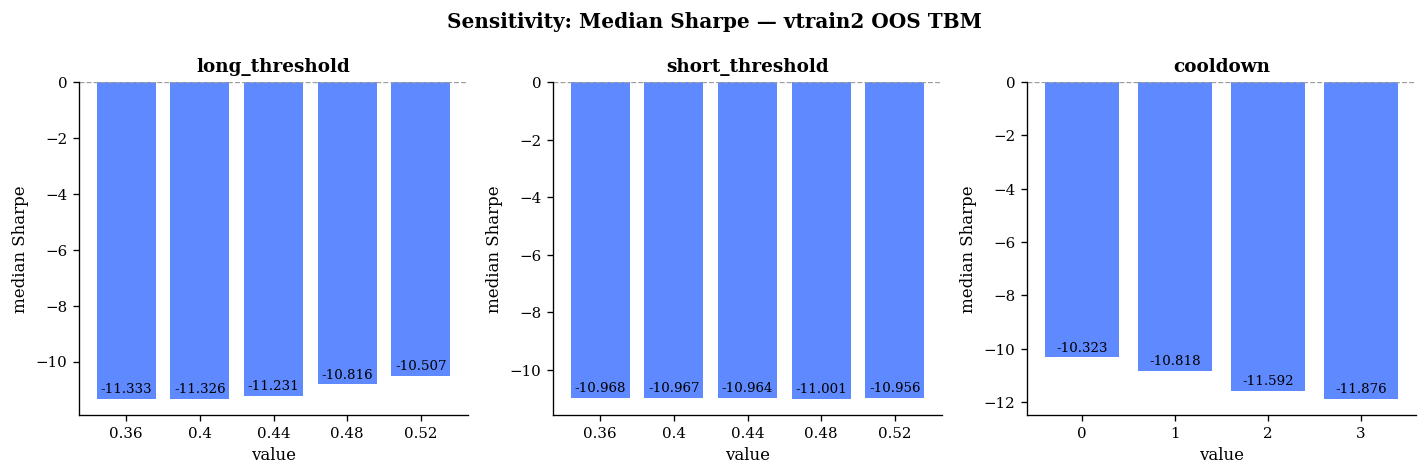

In [10]:
if not results_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['sharpe'].median()
        ax.bar(grp.index.astype(str), grp.values, color=BLUE, alpha=0.75)
        ax.axhline(0, color=GREY, ls='--', lw=0.8)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('value'); ax.set_ylabel('median Sharpe')
        for i, (v, h) in enumerate(zip(grp.index.astype(str), grp.values)):
            ax.text(i, h + abs(h)*0.02, f'{h:.3f}', ha='center', fontsize=8)
    fig.suptitle('Sensitivity: Median Sharpe — vtrain2 OOS TBM', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_sensitivity_vtrain2.png')
    plt.show()

Best configuration (OOS TBM grid):
  long_threshold         = 0.52
  short_threshold        = 0.52
  cooldown               = 3.0

  OOS TBM backtest: 8754 trades  return=-100.00%  Sharpe=-9.261  MaxDD=-100.00%


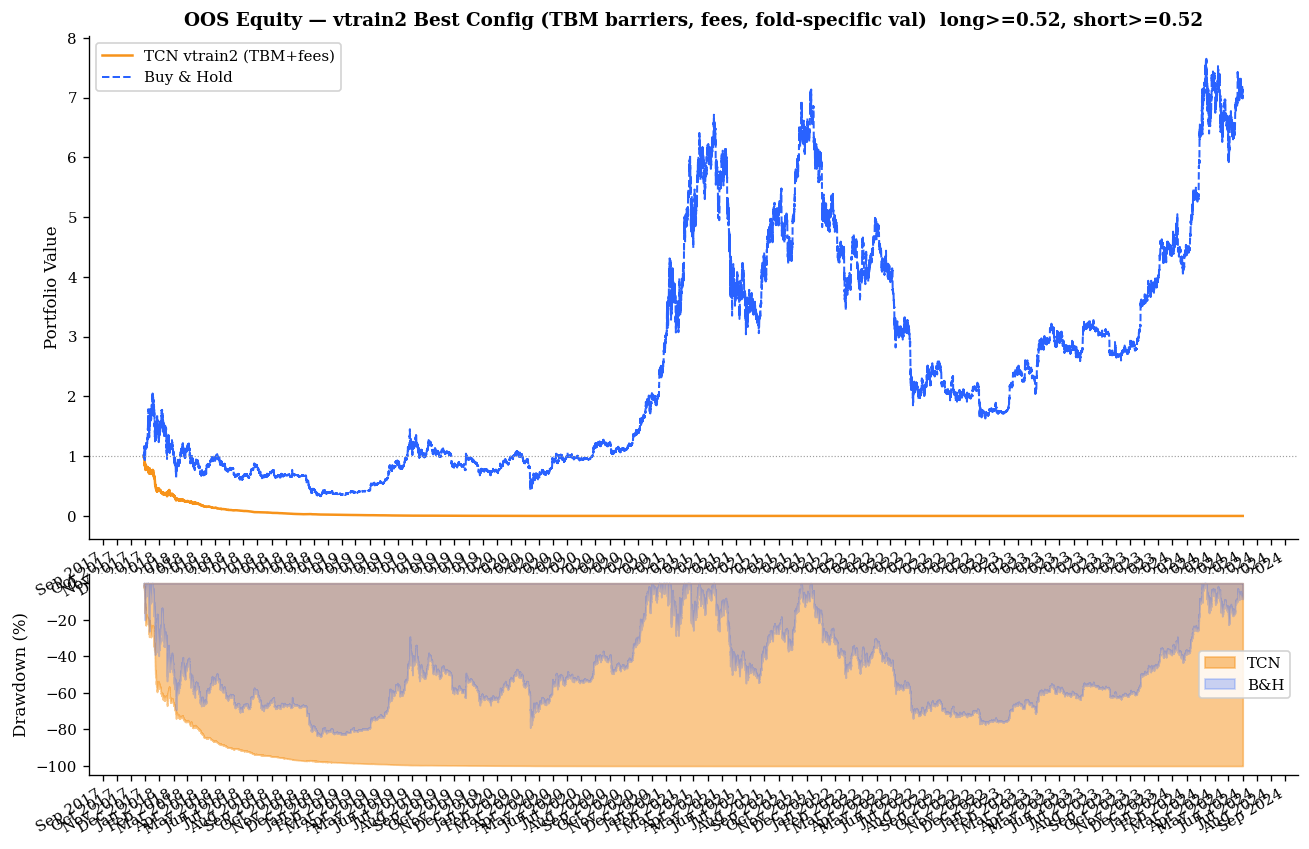

In [11]:
if results_df.empty:
    print('No grid results.')
else:
    best      = results_df.sort_values(OPTIMISE_METRIC, ascending=False).iloc[0]
    best_p    = {k: best[k] for k in keys}
    print('Best configuration (OOS TBM grid):')
    for k, v in best_p.items(): print(f'  {k:<22} = {v}')

    # Re-run to get equity curve
    lt = best_p['long_threshold']; st = best_p['short_threshold']; cd = int(best_p['cooldown'])

    cash = 1.0; units = 0.0; entry_cash = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; upper = 0.0; lower = 0.0
    bars_held = 0; cooldown = 0
    equity_oos = []; trade_log = []

    for i in range(len(oos_close_v)):
        px = oos_close_v[i]; hi = oos_high_v[i]; lo = oos_low_v[i]
        p_up = oos_up_v[i]; p_dn = oos_down_v[i]; vol = oos_vol_v[i]
        ts   = oos_index_v[i]
        if cooldown > 0: cooldown -= 1

        if in_pos:
            bars_held += 1; reason = None; exit_px = px
            if direction == 'long':
                if lo <= lower and hi >= upper: reason = 'sl'; exit_px = lower
                elif lo <= lower: reason = 'sl'; exit_px = lower
                elif hi >= upper: reason = 'tp'; exit_px = upper
                elif bars_held >= TBM_VERT_H: reason = 'vert'
                if reason:
                    pnl = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - FEE_RATE); units = 0.0
            else:
                if hi >= upper and lo <= lower: reason = 'sl'; exit_px = upper
                elif hi >= upper: reason = 'sl'; exit_px = upper
                elif lo <= lower: reason = 'tp'; exit_px = lower
                elif bars_held >= TBM_VERT_H: reason = 'vert'
                if reason:
                    pnl  = (entry_px - exit_px) / entry_px
                    cash = entry_cash * (1.0 + pnl) * (1.0 - FEE_RATE)
            if reason:
                trade_log.append({'entry_time': entry_ts, 'exit_time': ts,
                                  'direction': direction, 'pnl_pct': pnl, 'reason': reason,
                                  'hold_h': bars_held})
                in_pos = False; bars_held = 0; cooldown = cd

        if not in_pos and cooldown == 0 and not np.isnan(vol) and vol > 0:
            if p_up >= lt:
                upper = px * (1.0 + TBM_PT * vol); lower = px * (1.0 - TBM_SL * vol)
                units = cash * (1.0 - FEE_RATE) / px; cash = 0.0
                in_pos = True; direction = 'long'; entry_px = px; entry_ts = ts; bars_held = 0
            elif p_dn >= st and p_up < lt:
                upper = px * (1.0 + TBM_SL * vol); lower = px * (1.0 - TBM_PT * vol)
                entry_cash = cash * (1.0 - FEE_RATE); cash = 0.0; units = entry_cash / px
                in_pos = True; direction = 'short'; entry_px = px; entry_ts = ts; bars_held = 0

        if in_pos and direction == 'long': equity_oos.append(units * px)
        elif in_pos and direction == 'short': equity_oos.append(entry_cash * (1.0 + (entry_px - px) / entry_px))
        else: equity_oos.append(cash)

    if in_pos:
        px = oos_close_v[-1]
        if direction == 'long': pnl = (px - entry_px) / entry_px; equity_oos[-1] = units * px * (1-FEE_RATE)
        else: pnl = (entry_px - px)/entry_px; equity_oos[-1] = entry_cash*(1+pnl)*(1-FEE_RATE)

    eq_oos_arr  = np.array(equity_oos)
    trades_oos  = pd.DataFrame(trade_log)

    def _sharpe(eq): r = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    def _maxdd(eq):  pk = np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

    print(f'\n  OOS TBM backtest: {len(trades_oos)} trades  '
          f'return={eq_oos_arr[-1]-1:+.2%}  Sharpe={_sharpe(eq_oos_arr):.3f}  '
          f'MaxDD={_maxdd(eq_oos_arr):.2%}')

    fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                             gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})
    ax = axes[0]
    ax.plot(oos_index_v, eq_oos_arr,    color=ACCENT, lw=1.5, label='TCN vtrain2 (TBM+fees)')
    ax.plot(oos_index_v, bh_equity_oos, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':'); ax.set_ylabel('Portfolio Value'); ax.legend()
    ax.set_title(f'OOS Equity — vtrain2 Best Config (TBM barriers, fees, fold-specific val)  '
                 f'long>={lt}, short>={st}', fontweight='bold')
    ax = axes[1]
    pk_s = np.maximum.accumulate(eq_oos_arr); pk_b = np.maximum.accumulate(bh_equity_oos)
    ax.fill_between(oos_index_v, (eq_oos_arr - pk_s)/(pk_s+1e-12)*100, 0, color=ACCENT, alpha=0.5, label='TCN')
    ax.fill_between(oos_index_v, (bh_equity_oos - pk_b)/(pk_b+1e-12)*100, 0, color=BLUE, alpha=0.25, label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend()
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.savefig(FIGURES_DIR / 'tcn_grid_oos_equity_vtrain2.png'); plt.show()

## Phase 3 — Walk-Forward Optimization (WFO)

**Fix applied**: vtrain1 applied a static production model to the entire test set. vtrain2 retrains monthly:
- Load `tcn_model.pt` as initial weights
- Monthly steps (`WFO_STEP_H=720h`)
- Each step: fine-tune 5 epochs on a rolling 4-month window (`WFO_FINETUNE_WINDOW=2880h`) using the **best params found in Phase 2**
- Warm-start: next step loads previous step's best weights
- Predict on the next `WFO_STEP_H` bars with TBM backtest + fees

Comparison: vtrain1 static backtest vs vtrain2 WFO — both using TBM execution and fees.

In [12]:
if results_df.empty:
    raise RuntimeError('Grid search produced no results — cannot run WFO.')

# ── Combine all data for WFO ─────────────────────────────────────────────────
all_df      = pd.concat([train_df, val_df, test_df])
N_TV        = len(train_df) + len(val_df)   # rows before test period
N_ALL       = len(all_df)

X_all_qt    = qt.transform(all_df[ALL_INPUT_FEATS].values).astype(np.float32)
y_all       = all_df['tbm_label'].values.astype(np.int64)
w_all       = all_df['sample_weight'].values.astype(np.float32)
v_all       = all_df['fwd_vol'].values.astype(np.float32)

all_close   = all_df['close'].values.astype(np.float64)
all_high    = all_df['high'].values.astype(np.float64)
all_low     = all_df['low'].values.astype(np.float64)
all_vol     = all_df['rolling_vol'].values.astype(np.float64)
all_index   = all_df.index

n_test_rows = N_ALL - N_TV
n_steps     = max(1, (n_test_rows - WFO_STEP_H) // WFO_STEP_H + 1)

print(f'N_TV={N_TV:,}  N_ALL={N_ALL:,}  n_test_rows={n_test_rows:,}  n_steps={n_steps}')
print(f'WFO covers: {all_index[N_TV].date()} → {all_index[min(N_TV + n_steps*WFO_STEP_H - 1, N_ALL-1)].date()}')

# ── Load production model as WFO starting point ───────────────────────────────
qt_prod     = pickle.loads((MODELS_DIR / 'tcn_qt.pkl').read_bytes())
wfo_model   = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT)
wfo_model.load_state_dict(torch.load(MODELS_DIR / 'tcn_model.pt', map_location='cpu'))
wfo_model   = wfo_model.to(DEVICE)
print('Production model loaded as WFO starting point.')

# ── Best grid params for TBM backtest ─────────────────────────────────────────
best_lt = float(best_p['long_threshold'])
best_st = float(best_p['short_threshold'])
best_cd = int(best_p['cooldown'])
print(f'Using best grid params: long>={best_lt}, short>={best_st}, cooldown={best_cd}')

N_TV=60,837  N_ALL=74,073  n_test_rows=13,236  n_steps=18
WFO covers: 2024-11-10 → 2026-05-04
Production model loaded as WFO starting point.
Using best grid params: long>=0.52, short>=0.52, cooldown=3


In [13]:
wfo_probs_up   = np.full(n_test_rows, np.nan, dtype=np.float32)
wfo_probs_down = np.full(n_test_rows, np.nan, dtype=np.float32)

best_wfo_state = {kk: vv.cpu().clone() for kk, vv in wfo_model.state_dict().items()}

for t in range(n_steps):
    step_start = N_TV + t * WFO_STEP_H
    step_end   = min(N_TV + (t + 1) * WFO_STEP_H, N_ALL)
    if step_start >= N_ALL: break

    # ── Fine-tuning window ────────────────────────────────────────────────────
    n_window    = step_start
    n_int_wfo   = min(WFO_INTERNAL_VAL_H, max(50, int(0.08 * n_window)))
    ft_end      = n_window - n_int_wfo
    ft_start    = max(SEQ_LEN, ft_end - WFO_FINETUNE_WINDOW)
    int_start_w = ft_end
    int_end_w   = n_window

    # Build fine-tuning sequences
    X_ft_ctx   = X_all_qt[ft_start - (SEQ_LEN - 1) : ft_end]
    ft_seqs    = np.stack([X_ft_ctx[i:i+SEQ_LEN] for i in range(len(X_ft_ctx) - SEQ_LEN + 1)],
                           axis=0).astype(np.float32)
    y_ft       = y_all[ft_start:ft_end]
    w_ft       = w_all[ft_start:ft_end]
    v_ft       = v_all[ft_start:ft_end]
    n_ft       = len(ft_seqs)

    # Build internal val sequences
    X_int_ctx  = X_all_qt[int_start_w - (SEQ_LEN - 1) : int_end_w]
    int_seqs   = np.stack([X_int_ctx[i:i+SEQ_LEN] for i in range(len(X_int_ctx) - SEQ_LEN + 1)],
                           axis=0).astype(np.float32)
    y_int      = y_all[int_start_w:int_end_w]
    v_int      = v_all[int_start_w:int_end_w]
    n_iv       = len(int_seqs)

    if n_ft < SEQ_LEN or n_iv < 2:
        print(f'  Step {t}: insufficient data (ft={n_ft}, val={n_iv}) — predicting with current model')
    else:
        # Fine-tune from warm-start weights
        ft_model = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT)
        ft_model.load_state_dict(best_wfo_state)
        ft_model = ft_model.to(DEVICE)

        ccs = np.bincount(y_ft, minlength=3).astype(np.float32)
        cw  = torch.tensor(ccs.sum() / (3 * ccs + 1e-8), dtype=torch.float32).to(DEVICE)
        opt = torch.optim.AdamW(ft_model.parameters(), lr=WFO_LR, weight_decay=WEIGHT_DECAY)

        loader_ft  = DataLoader(TensorDataset(
            torch.from_numpy(ft_seqs),
            torch.from_numpy(y_ft.astype(np.int64)),
            torch.from_numpy(w_ft.astype(np.float32)),
            torch.from_numpy(v_ft.astype(np.float32))),
            batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        loader_iv  = DataLoader(TensorDataset(
            torch.from_numpy(int_seqs),
            torch.from_numpy(y_int.astype(np.int64)),
            torch.from_numpy(v_int.astype(np.float32))),
            batch_size=256, shuffle=False, num_workers=0)

        best_iv_loss = np.inf; pat = 0; best_ft_state = best_wfo_state

        for ep in range(WFO_FINETUNE_EPOCHS):
            ft_model.train()
            for xb, yb, wb, vb in loader_ft:
                xb,yb,wb,vb = xb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
                opt.zero_grad()
                lgts, vp = ft_model(xb)
                loss = (F.cross_entropy(lgts,yb,weight=cw,reduction='none')*wb).mean() + \
                       LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
                opt.step()

            ft_model.eval(); iv_acc = 0.0
            with torch.no_grad():
                for xb, yb, vb in loader_iv:
                    xb,yb,vb = xb.to(DEVICE),yb.to(DEVICE),vb.to(DEVICE)
                    lgts,vp  = ft_model(xb)
                    iv_acc  += (F.cross_entropy(lgts,yb) + LAMBDA_VOL*F.huber_loss(vp,vb)).item()*len(xb)
            iv_loss = iv_acc / max(len(loader_iv.dataset), 1)
            if iv_loss < best_iv_loss:
                best_iv_loss  = iv_loss
                best_ft_state = {kk: vv.cpu().clone() for kk, vv in ft_model.state_dict().items()}
                pat = 0
            else:
                pat += 1
            if pat >= WFO_PATIENCE: break

        best_wfo_state = best_ft_state   # warm-start for next step
        ft_model.cpu(); del ft_model
        if DEVICE.type == 'mps': torch.mps.empty_cache()

    # ── Predict on step window ─────────────────────────────────────────────────
    pred_start  = step_start
    pred_end    = step_end
    X_pred_ctx  = X_all_qt[pred_start - (SEQ_LEN - 1) : pred_end]
    pred_seqs   = np.stack([X_pred_ctx[i:i+SEQ_LEN] for i in range(len(X_pred_ctx) - SEQ_LEN + 1)],
                            axis=0).astype(np.float32)
    n_pred      = len(pred_seqs)

    pred_model  = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT)
    pred_model.load_state_dict(best_wfo_state)
    pred_model  = pred_model.to(DEVICE)
    pred_model.eval()

    lgts_list = []
    with torch.no_grad():
        for xb, in DataLoader(TensorDataset(torch.from_numpy(pred_seqs)), batch_size=512):
            lgts, _ = pred_model(xb.to(DEVICE))
            lgts_list.append(lgts.cpu())
    probs_step  = torch.softmax(torch.cat(lgts_list), dim=1).numpy()

    # Store (offset by N_TV since wfo_probs_* is indexed from test start)
    rel_start   = t * WFO_STEP_H
    rel_end     = rel_start + n_pred
    wfo_probs_up[rel_start:rel_end]   = probs_step[:, 1]
    wfo_probs_down[rel_start:rel_end] = probs_step[:, 0]

    pred_model.cpu(); del pred_model
    if DEVICE.type == 'mps': torch.mps.empty_cache()

    print(f'  Step {t+1}/{n_steps}: predict [{pred_start},{pred_end})  '
          f'({all_index[pred_start].date()}→{all_index[pred_end-1].date()})  '
          f'n_pred={n_pred}')

wfo_valid = ~np.isnan(wfo_probs_up)
print(f'\nWFO coverage: {wfo_valid.sum():,}/{n_test_rows:,}')

  Step 1/18: predict [60837,61557)  (2024-11-10→2024-12-10)  n_pred=720
  Step 2/18: predict [61557,62277)  (2024-12-10→2025-01-09)  n_pred=720
  Step 3/18: predict [62277,62997)  (2025-01-09→2025-02-08)  n_pred=720
  Step 4/18: predict [62997,63717)  (2025-02-08→2025-03-10)  n_pred=720
  Step 5/18: predict [63717,64437)  (2025-03-10→2025-04-09)  n_pred=720
  Step 6/18: predict [64437,65157)  (2025-04-09→2025-05-09)  n_pred=720
  Step 7/18: predict [65157,65877)  (2025-05-09→2025-06-08)  n_pred=720
  Step 8/18: predict [65877,66597)  (2025-06-08→2025-07-08)  n_pred=720
  Step 9/18: predict [66597,67317)  (2025-07-08→2025-08-07)  n_pred=720
  Step 10/18: predict [67317,68037)  (2025-08-07→2025-09-06)  n_pred=720
  Step 11/18: predict [68037,68757)  (2025-09-06→2025-10-06)  n_pred=720
  Step 12/18: predict [68757,69477)  (2025-10-06→2025-11-05)  n_pred=720
  Step 13/18: predict [69477,70197)  (2025-11-05→2025-12-05)  n_pred=720
  Step 14/18: predict [70197,70917)  (2025-12-05→2026-01-04)

In [14]:
# ── WFO backtest with best grid params, TBM barriers, fees ───────────────────
wfo_mask        = ~np.isnan(wfo_probs_up)
wfo_up_v        = wfo_probs_up[wfo_mask]
wfo_down_v      = wfo_probs_down[wfo_mask]
wfo_close_v     = all_close[N_TV:][wfo_mask]
wfo_high_v      = all_high[N_TV:][wfo_mask]
wfo_low_v       = all_low[N_TV:][wfo_mask]
wfo_vol_v       = all_vol[N_TV:][wfo_mask]
wfo_index_v     = all_index[N_TV:][wfo_mask]
wfo_bh_equity   = wfo_close_v / wfo_close_v[0]

wfo_result = run_backtest_tbm(
    wfo_up_v, wfo_down_v, wfo_close_v, wfo_high_v, wfo_low_v, wfo_vol_v,
    {'long_threshold': best_lt, 'short_threshold': best_st, 'cooldown': best_cd}
)

# ── Static prod model backtest (vtrain1-style but with TBM+fees for fair comparison) ──
qt_prod     = pickle.loads((MODELS_DIR / 'tcn_qt.pkl').read_bytes())
prod_model  = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
prod_model.load_state_dict(torch.load(MODELS_DIR / 'tcn_model.pt', map_location=DEVICE))
prod_model.eval()

X_test_qt   = qt_prod.transform(test_df[ALL_INPUT_FEATS].values).astype(np.float32)
test_seqs   = np.stack([X_test_qt[i:i+SEQ_LEN] for i in range(len(X_test_qt) - SEQ_LEN + 1)],
                        axis=0).astype(np.float32)
lgts_list = []
with torch.no_grad():
    for xb, in DataLoader(TensorDataset(torch.from_numpy(test_seqs)), batch_size=512):
        lgts, _ = prod_model(xb.to(DEVICE))
        lgts_list.append(lgts.cpu())
probs_static = torch.softmax(torch.cat(lgts_list), dim=1).numpy()

static_close = test_df['close'].values[SEQ_LEN:].astype(np.float64)
static_high  = test_df['high'].values[SEQ_LEN:].astype(np.float64)
static_low   = test_df['low'].values[SEQ_LEN:].astype(np.float64)
static_vol   = test_df['rolling_vol'].values[SEQ_LEN:].astype(np.float64)
static_index = test_df.index[SEQ_LEN:]
static_bh    = static_close / static_close[0]

static_result = run_backtest_tbm(
    probs_static[:, 1], probs_static[:, 0],
    static_close, static_high, static_low, static_vol,
    {'long_threshold': best_lt, 'short_threshold': best_st, 'cooldown': best_cd}
)

prod_model.cpu(); del prod_model
if DEVICE.type == 'mps': torch.mps.empty_cache()

print('='*65)
print('  FINAL COMPARISON: Static prod model vs WFO fine-tuned model')
print('  (both using TBM barriers + fees — fair comparison)')
print('='*65)
for label, res in [('Static (prod model)', static_result), ('WFO vtrain2', wfo_result)]:
    if res is None:
        print(f'  {label}: insufficient trades')
        continue
    print(f'  {label}:')
    print(f'    Trades (L/S): {res["n_trades"]} ({res["n_long"]}/{res["n_short"]})')
    print(f'    Exit reasons: SL={res["n_sl"]}  TP={res["n_tp"]}  Vert={res["n_vert"]}')
    print(f'    Win rate    : {res["win_rate"]:.1%}')
    print(f'    Return      : {res["total_return"]:+.2%}')
    print(f'    Sharpe      : {res["sharpe"]:.3f}')
    print(f'    Max DD      : {res["max_dd"]:.2%}')
    print(f'    Calmar      : {res["calmar"]:.3f}')
print('='*65)
print(f'  Buy & Hold: {(static_bh[-1]-1):+.2%}')

  FINAL COMPARISON: Static prod model vs WFO fine-tuned model
  (both using TBM barriers + fees — fair comparison)
  Static (prod model):
    Trades (L/S): 205 (142/63)
    Exit reasons: SL=97  TP=108  Vert=0
    Win rate    : 52.7%
    Return      : -34.00%
    Sharpe      : -4.006
    Max DD      : -34.54%
    Calmar      : -0.984
  WFO vtrain2:
    Trades (L/S): 933 (463/470)
    Exit reasons: SL=492  TP=432  Vert=9
    Win rate    : 46.9%
    Return      : -88.52%
    Sharpe      : -10.703
    Max DD      : -88.56%
    Calmar      : -1.000
  Buy & Hold: -1.02%


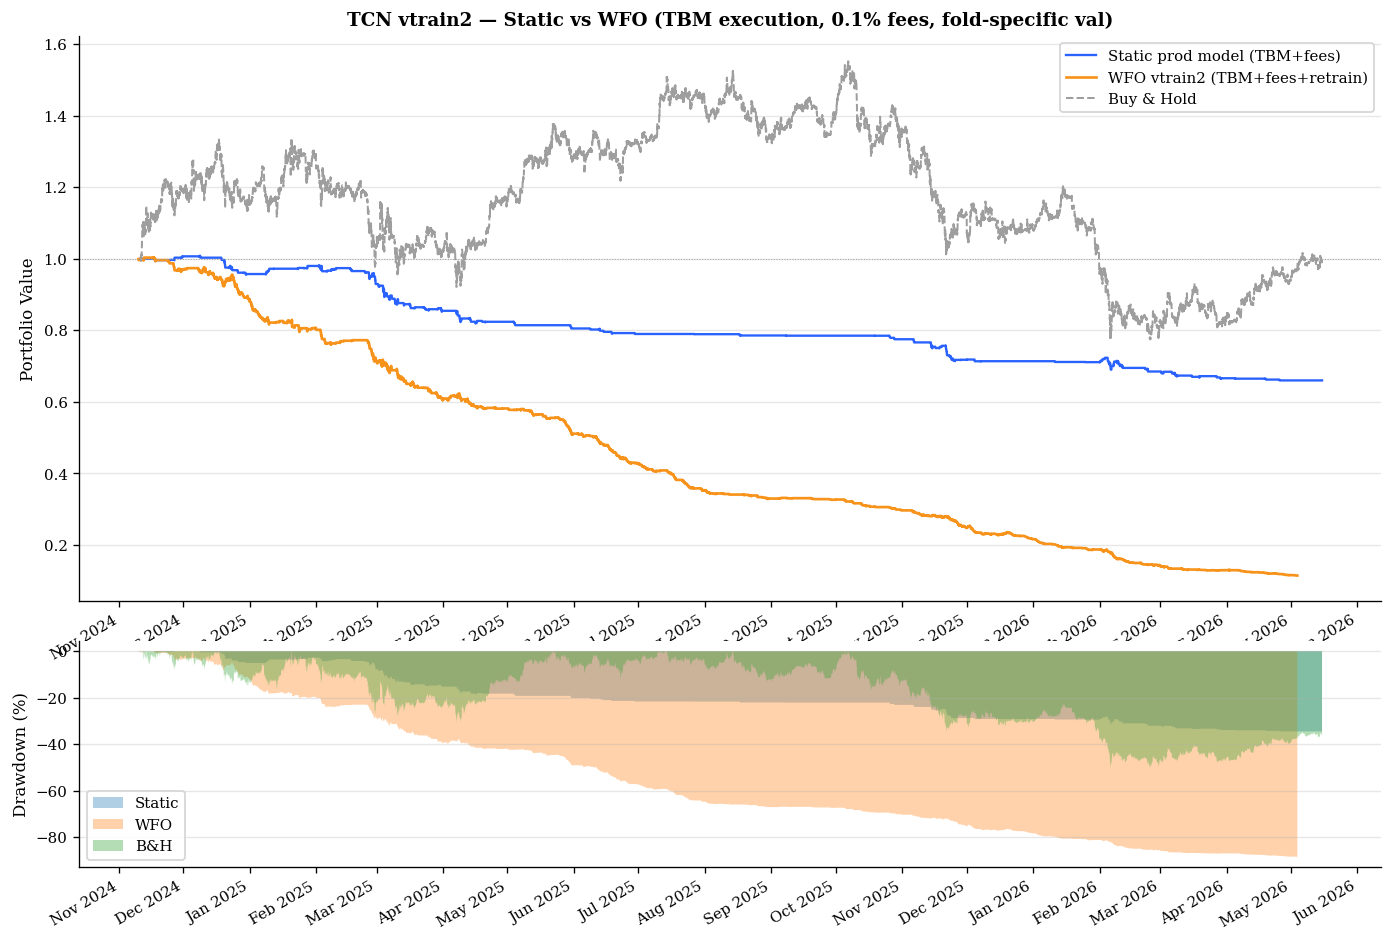

In [15]:
# ── Re-run with equity curve for plotting ─────────────────────────────────────
def full_backtest_tbm_curve(probs_up, probs_down, close_arr, high_arr, low_arr, vol_arr,
                             lt, st, cd, tbm_pt=TBM_PT, tbm_sl=TBM_SL, vert_h=TBM_VERT_H, fee=FEE_RATE):
    N = len(close_arr)
    cash=1.0; units=0.0; entry_cash=0.0; in_pos=False; direction=None
    entry_px=0.0; upper=0.0; lower=0.0; bars_held=0; cooldown=0
    equity = np.empty(N, dtype=np.float64)
    for i in range(N):
        px=close_arr[i]; hi=high_arr[i]; lo=low_arr[i]
        p_up=probs_up[i]; p_dn=probs_down[i]; vol=vol_arr[i]
        if cooldown > 0: cooldown -= 1
        if in_pos:
            bars_held += 1; reason=None; exit_px=px
            if direction == 'long':
                if lo<=lower and hi>=upper: reason='sl'; exit_px=lower
                elif lo<=lower: reason='sl'; exit_px=lower
                elif hi>=upper: reason='tp'; exit_px=upper
                elif bars_held>=vert_h: reason='vert'
                if reason: pnl=(exit_px-entry_px)/entry_px; cash=units*exit_px*(1-fee); units=0.0
            else:
                if hi>=upper and lo<=lower: reason='sl'; exit_px=upper
                elif hi>=upper: reason='sl'; exit_px=upper
                elif lo<=lower: reason='tp'; exit_px=lower
                elif bars_held>=vert_h: reason='vert'
                if reason: pnl=(entry_px-exit_px)/entry_px; cash=entry_cash*(1+pnl)*(1-fee)
            if reason: in_pos=False; bars_held=0; cooldown=cd
        if not in_pos and cooldown==0 and not np.isnan(vol) and vol>0:
            if p_up>=lt:
                upper=px*(1+tbm_pt*vol); lower=px*(1-tbm_sl*vol)
                units=cash*(1-fee)/px; cash=0.0; in_pos=True; direction='long'; entry_px=px; bars_held=0
            elif p_dn>=st and p_up<lt:
                upper=px*(1+tbm_sl*vol); lower=px*(1-tbm_pt*vol)
                entry_cash=cash*(1-fee); cash=0.0; units=entry_cash/px
                in_pos=True; direction='short'; entry_px=px; bars_held=0
        equity[i] = units*px if (in_pos and direction=='long') else \
                    (entry_cash*(1+(entry_px-px)/entry_px) if (in_pos and direction=='short') else cash)
    if in_pos:
        px=close_arr[-1]
        if direction=='long': equity[-1]=units*px*(1-fee)
        else: equity[-1]=entry_cash*(1+(entry_px-px)/entry_px)*(1-fee)
    return equity

eq_static = full_backtest_tbm_curve(
    probs_static[:,1], probs_static[:,0], static_close, static_high, static_low, static_vol,
    best_lt, best_st, best_cd)

eq_wfo = full_backtest_tbm_curve(
    wfo_up_v, wfo_down_v, wfo_close_v, wfo_high_v, wfo_low_v, wfo_vol_v,
    best_lt, best_st, best_cd)

# Align indices for plotting (use static_index as common denominator)
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})
ax = axes[0]
ax.plot(static_index, eq_static,  color=BLUE,   lw=1.4, label='Static prod model (TBM+fees)')
ax.plot(wfo_index_v,  eq_wfo,     color=ACCENT, lw=1.6, label='WFO vtrain2 (TBM+fees+retrain)')
ax.plot(static_index, static_bh,  color=GREY,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.6, ls=':')
ax.set_ylabel('Portfolio Value'); ax.legend()
ax.set_title('TCN vtrain2 — Static vs WFO (TBM execution, 0.1% fees, fold-specific val)',
             fontweight='bold')
ax = axes[1]
for eq, idx, color, lbl in [
    (eq_static, static_index, BLUE,   'Static'),
    (eq_wfo,    wfo_index_v,  ACCENT, 'WFO'),
    (static_bh, static_index, GREY,   'B&H'),
]:
    pk = np.maximum.accumulate(eq)
    ax.fill_between(idx, (eq-pk)/(pk+1e-12)*100, 0, alpha=0.35, label=lbl)
ax.set_ylabel('Drawdown (%)'); ax.legend()
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(axis='y', alpha=0.3)
fig.savefig(FIGURES_DIR / 'tcn_backtest_results_vtrain2.png'); plt.show()

In [16]:
if not results_df.empty:
    # Grid results
    out_csv = MODELS_DIR / 'tcn_grid_results_vtrain2.csv'
    results_df.sort_values(OPTIMISE_METRIC, ascending=False).to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    def _s(eq): r=np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    def _d(eq): pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

    out = {
        'long_threshold':  best_lt,
        'short_threshold': best_st,
        'cooldown':        best_cd,
        'optimised_metric': OPTIMISE_METRIC,
        'selection_method': 'purged_kfold_oos_fold_specific_val',
        'K': K, 'embargo': EMBARGO,
        'kfold_internal_val_h': KFOLD_INTERNAL_VAL_H,
        'backtest': 'TBM_barriers_intracandle_fees',
        'fee_rate': FEE_RATE,
        # OOS grid metrics
        'oos_sharpe':       round(float(best['sharpe']), 4),
        'oos_total_return': round(float(best['total_return']), 4),
        'oos_max_dd':       round(float(best['max_dd']), 4),
        'oos_n_trades':     int(best['n_trades']),
        # Static test (same params, fair TBM+fees baseline)
        'static_sharpe':       round(_s(eq_static), 4) if static_result else None,
        'static_total_return': round(float(eq_static[-1]-1), 4) if static_result else None,
        'static_max_dd':       round(_d(eq_static), 4) if static_result else None,
        'static_n_trades':     int(static_result['n_trades']) if static_result else None,
        # WFO test
        'wfo_sharpe':       round(_s(eq_wfo), 4) if wfo_result else None,
        'wfo_total_return': round(float(eq_wfo[-1]-1), 4) if wfo_result else None,
        'wfo_max_dd':       round(_d(eq_wfo), 4) if wfo_result else None,
        'wfo_n_trades':     int(wfo_result['n_trades']) if wfo_result else None,
    }

    out_json = MODELS_DIR / 'tcn_best_trading_params_vtrain2.json'
    with open(out_json, 'w') as f:
        json.dump(out, f, indent=2)
    print(f'Saved: {out_json}')
    print()
    print(json.dumps(out, indent=2))

Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_grid_results_vtrain2.csv
Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_best_trading_params_vtrain2.json

{
  "long_threshold": 0.52,
  "short_threshold": 0.52,
  "cooldown": 3,
  "optimised_metric": "sharpe",
  "selection_method": "purged_kfold_oos_fold_specific_val",
  "K": 5,
  "embargo": 168,
  "kfold_internal_val_h": 1500,
  "backtest": "TBM_barriers_intracandle_fees",
  "fee_rate": 0.001,
  "oos_sharpe": -9.2614,
  "oos_total_return": -1.0,
  "oos_max_dd": -1.0,
  "oos_n_trades": 8754,
  "static_sharpe": -4.0063,
  "static_total_return": -0.34,
  "static_max_dd": -0.3454,
  "static_n_trades": 205,
  "wfo_sharpe": -10.7031,
  "wfo_total_return": -0.8852,
  "wfo_max_dd": -0.8856,
  "wfo_n_trades": 933
}
